### Step 0: Imports

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.io import loadmat
from matplotlib import pyplot as plt
from scipy.stats import norm, nbinom, geom, gamma, fisk, gompertz, invgauss, skew, binom, logistic 
from scipy.optimize import minimize

### Step 1: Extract leaving times 

In [4]:
# Search for data related to Calvin
root = Path("/Users/tomroper/Projects/Foraging/Leaving Variability/Patch/calvin")
mats = sorted(root.rglob("*.mat"))

# Go through each session, reformat it from matlab file and append to a list 
trialData = []
for p in mats:
    dataFile = loadmat(str(p), squeeze_me=True, simplify_cells=True)
    data = dataFile["data"]
    for tr in data:
        trialData.append(tr)


choices = np.array([str(tr["choiceMade"]).lower() for tr in trialData], dtype=object)

# This finds the indices where Calvin left and indicate the patch boundary 
leaveIdx = np.flatnonzero((choices[1:] == "leave") & (choices[:-1] == "stay")) + 1

# Extract how many stay decisions there are before the leave
patches = []
for li in leaveIdx:
    k = li - 1
    stay_count = 0
    while k >= 0 and choices[k] == "stay":
        stay_count += 1
        k -= 1
    patches.append({"length": stay_count})

patchLengths = np.array([p["length"] for p in patches], dtype=float)
patchLengths = patchLengths[patchLengths >= 1]  # Remove any patches with 0 stay decisions
patchLength_mean = np.nanmean(patchLengths)
raw_trials_total_stays = int(np.nansum(patchLengths))

print("monkey: Calvin")
print("n_sessions:", len(mats))
print("n_patches:", len(patchLengths))
print("n_trials:", raw_trials_total_stays)
print("Mean PRT:", round(patchLength_mean, 3))

monkey: Calvin
n_sessions: 33
n_patches: 2025
n_trials: 14413
Mean PRT: 7.118


### Step 2: Replicate the graph in the paper

- Note: The graph matches the figure in the paper, but the mean PRT does not

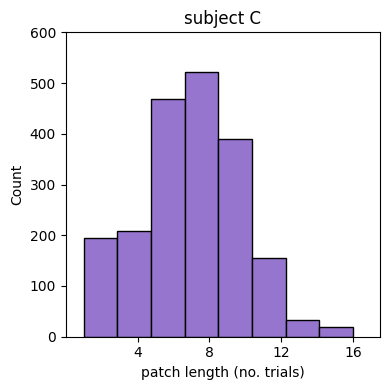

number of patches: 1991
Mean PRT: 6.897


In [5]:
x = patchLengths[patchLengths <= 16] # They remove outliers for the figure in the original paper

plt.figure(figsize=(4, 4))
plt.hist(x, bins=8, edgecolor="black", color="#9575cd")
plt.ylim(0, 600)
plt.xlim(0, 17.5)
plt.xlabel("patch length (no. trials)")
plt.ylabel("Count")
plt.title(f"subject C")
plt.xticks([4,8,12,16])
plt.tight_layout()
plt.show()

print(f"number of patches: {len(x)}")
print(f"Mean PRT: {round(np.nanmean(x), 3)}")

### Step 3: Replot the graph with more bins

- Plotting the distribution with more bins exposes the slightly weirder shape of the distribution (particularly the peak at 1 stay decision)

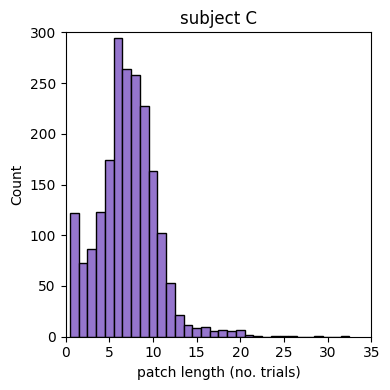

In [6]:
x = patchLengths

plt.figure(figsize=(4, 4))
edges = np.arange(x.min(), x.max() + 2) - 0.5
_, bin_edges, _ = plt.hist(x, bins=edges, edgecolor="black", color="#9575cd")
plt.ylim(0, 300)
plt.xlim(0, 35)
plt.xlabel("patch length (no. trials)")
plt.ylabel("Count")
plt.title(f"subject C")
plt.tight_layout()
plt.show()

### Step 4: Fitting standard distributions to the data

To check:
-   negative binomial
-   discrete weibull
-   discrete gamma
-   discrete lognormal
-   geometric
-   beta-geometric

In [7]:
class DistributionFitter:
    """
    Fits a distribution to our patch leaving times by finding the parameters of the distribution that minimizes the negative log-likelihood between the distribution and the observations.
    You pass in your nll function, init, bounds, and param_names.
    """

    def __init__(self, name, nll_func, init, param_names, bounds=None):
        """
        Parameters
        ----------
        name : str
            Label for this distribution (e.g. "weibull").

        nll_func : callable
            Negative log-likelihood: nll_func(params, x) -> scalar.
            params is a 1D array; x is the array of observations -> number of stays in each patch.

        init : array-like or callable
            Initial guess of the parameters

        param_names : list of str
            Names for each parameter (for the output params dict).

        bounds : list of (low, high) or None
            Bounds per parameter. Use None for unbounded. low/high can be None.

        """

        self.name = name
        self.nll_func = nll_func
        self.init = init
        self.param_names = param_names
        self.bounds = bounds

    def fit(self, x):
        """Fit to patch residency time observations. Returns (params, aic, bic)."""

        init = self.init
        result = minimize(
            self.nll_func, init, args=(x,), method="L-BFGS-B",
            bounds=self.bounds if self.bounds is not None else [(None, None)] * len(init), # if we dont pass bounds, just use None
        )

        k = len(init) # number of parameters
        N = len(x) # number of observations
        params = {name: round(v, 2) for name, v in zip(self.param_names, result.x)}
        aic = 2 * k + 2 * result.fun
        bic = k * np.log(N) + 2 * result.fun
        return params, aic, bic

    def fit_row(self, x):
        """Fit and return a row dict for appending to distributions_df."""
        params, aic, bic = self.fit(x)
        return {"distribution": self.name, "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}

In [8]:
def fit_distributions(x, fitters):
    """
    Fit multiple distributions and return a DataFrame sorted by AIC.
    """
    rows = [f.fit_row(x) for f in fitters]
    df = pd.DataFrame(rows).sort_values(by="aic").reset_index(drop=True)
    return df

In [9]:
def nll_discrete_lognormal(params, x):
    "Negative log likelihood of discrete lognormal distribution"

    # unpack parameters
    mu, sigma = params
    likelihood = np.zeros_like(x)

    # calculate likelihood of observations using discrete lognormal distribution
    # going to do different flow for x=1 to avoid runtime error from log(0)
    mask_1 = (x == 1)

    # first for x not = 1
    mask_not_1 = ~mask_1
    likelihood[mask_not_1] = norm.cdf(np.log(x[mask_not_1]), loc=mu, scale=sigma) - norm.cdf(np.log(x[mask_not_1]-1), loc=mu, scale=sigma)

    # for x = 1 the second term cancels out, and first term log(1) = 0
    likelihood[mask_1] = norm.cdf(0, loc=mu, scale=sigma)
    

    # prevent issues from log(0) due to python rounding down to 0
    likelihood = np.clip(likelihood, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihood))

    return nll


def nll_negative_binomial(params, x):
    "Negative log likelihood of negative binomial distribution"

    # unpack parameters
    r, p = params # r = number of failures, p = probability of success
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = nbinom.pmf(x-1, r, p)  # x-1 because x starts at 1, already discretised no p(x) - p(x-1) needed

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_geometric(params, x):
    "Negative log likelihood of the geometric distribution"

    # unpack parameters
    p = params #p = probability of success
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = geom.pmf(x, p) 

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_discrete_weibull(params, x):
    "Negative log likelihood of discrete weibull distribution"

    # unpack parameters
    q, beta = params
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = q ** ((x - 1) ** beta) - q ** (x ** beta)

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

def nll_gamma(params, x):
    "Negative log likelihood of the gamma distribution"

    # unpack parameters
    a, s = params # a = shape, s = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = gamma.cdf(x, a, scale=s) - gamma.cdf(x-1, a, scale=s)  # now we need to discretise again

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_log_logistic(params, x):
    "Negative log likelihood of the discretised log-logistic distribution"

    # unpack parameters
    k, lambda_ = params # k = shape, lambda_ = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = fisk.cdf(x, k, scale=lambda_) - fisk.cdf(x-1, k, scale=lambda_)  

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_gompertz(params, x):
    "Negative log likelihood of the discretised gompertz distribution"

    # unpack parameters
    eta, beta = params # eta = shape, beta = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = gompertz.cdf(x, eta, scale=beta) - gompertz.cdf(x-1, eta, scale=beta)  

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

In [10]:
fitters = [

    DistributionFitter("discrete lognormal", 
                        nll_discrete_lognormal, 
                        [1.8, 0.63],  # derived in different notebook
                        ["mu", "sigma"],
                       bounds=[(None, None), 
                               (None, None)]),

    DistributionFitter("discrete weibull", 
                        nll_discrete_weibull, 
                        [0.5, 1.0], 
                        ["q", "beta"],
                       bounds=[(1e-9, 1 - 1e-9), 
                               (1e-9, None)]),

    DistributionFitter("negative binomial", 
                        nll_negative_binomial, 
                        [1.0, 0.5], 
                        ["r", "p"],
                       bounds=[(1e-9, None), 
                               (1e-9, 1 - 1e-9)]),
                            
    DistributionFitter("geometric", 
                        nll_geometric, 
                        [0.5], 
                        ["p"],
                       bounds=[(1e-9, 1 - 1e-9)]),

    DistributionFitter("gamma", 
                        nll_gamma, 
                        [0.9, 1.0], 
                        ["a", "s"],
                       bounds=[(1e-9, None), 
                               (1e-9, None)]),

    DistributionFitter("discretelog-logistic", 
                        nll_log_logistic, 
                        [0.9, 1.0], 
                        ["k", "lambda_"],
                       bounds=[(1e-9, None), 
                               (1e-9, None)]),

    DistributionFitter("discrete gompertz", 
                        nll_gompertz, 
                        [0.9, 1.0], 
                        ["eta", "beta"],
                       bounds=[(1e-9, None), 
                               (1e-9, None)]),

]

# fit to the obs and create the fitting dataframe
df = fit_distributions(patchLengths, fitters)
df

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.94}",10706.28,10717.51
1,negative binomial,"{'r': 5.77, 'p': 0.49}",10706.32,10717.55
2,gamma,"{'a': 2.82, 's': 2.35}",10877.56,10888.79
3,discretelog-logistic,"{'k': 2.84, 'lambda_': 6.11}",11083.69,11094.92
4,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11361.38,11372.60
5,geometric,{'p': 0.14},11701.52,11707.13
6,discrete gompertz,"{'eta': 0.4, 'beta': 6.17}",12233.62,12244.85


### Step 5: Fitting 1-inflated distributions to the data

Same distributions as before, but now also 1-inflated

In [11]:
def nll_discrete_lognormal_inflated(params, x):
    "Negative log likelihood of discrete lognormal distribution, extra probability injected at x=1"

    # unpack parameters
    mu, sigma, pi = params
    likelihood = np.zeros_like(x, dtype=np.float64)

    # calculate likelihood of observations using discrete lognormal distribution
    # going to do different flow for x=1 to avoid runtime error from log(0)
    mask_1 = (x == 1)

    # first for x not = 1
    mask_not_1 = ~mask_1
    likelihood[mask_not_1] = (1-pi) * (norm.cdf(np.log(x[mask_not_1]), loc=mu, scale=sigma) - norm.cdf(np.log(x[mask_not_1]-1), loc=mu, scale=sigma))

    # for x = 1 the second term cancels out, and first term log(1) = 0
    likelihood[mask_1] = pi + (1-pi) * norm.cdf(0, loc=mu, scale=sigma)
    

    # prevent issues from log(0) due to python rounding down to 0
    likelihood = np.clip(likelihood, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihood))

    return nll


def nll_discrete_inverse_gaussian_inflated(params, x):
    "Negative log likelihood of negative binomial distribution, extra probability injected at x=1"

    # unpack parameters
    mu, scale, pi = params 
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * invgauss.cdf(1, mu=mu, scale=scale)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (invgauss.cdf(x[mask_not_1], mu=mu, scale=scale) - invgauss.cdf(x[mask_not_1] - 1, mu=mu, scale=scale))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_geometric_inflated(params, x):
    "Negative log likelihood of the geometric distribution, extra probability injected at x=1"

    # unpack parameters
    p, pi = params #p = probability of success
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * geom.pmf(1, p)

    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * geom.pmf(x[mask_not_1], p)

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_discrete_weibull_inflated(params, x):
    "Negative log likelihood of discrete weibull distribution, extra probability injected at x=1"

    # unpack parameters
    q, beta, pi = params
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * (q ** ((1 - 1) ** beta) - q ** (1 ** beta))

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (q ** ((x[mask_not_1] - 1) ** beta) - q ** (x[mask_not_1] ** beta))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

def nll_gamma_inflated(params, x):
    "Negative log likelihood of the gamma distribution, extra probability injected at x=1"

    # unpack parameters
    a, s, pi = params # a = shape, s = scale
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * gamma.cdf(1, a, scale=s)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (gamma.cdf(x[mask_not_1], a, scale=s) - gamma.cdf(x[mask_not_1]-1, a, scale=s))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_log_logistic_inflated(params, x):
    "Negative log likelihood of the discretised log-logistic distribution"

    # unpack parameters
    k, lambda_, pi = params # k = shape, lambda_ = scale
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * fisk.cdf(1, k, scale=lambda_)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (fisk.cdf(x[mask_not_1], k, scale=lambda_) - fisk.cdf(x[mask_not_1]-1, k, scale=lambda_))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_gompertz_inflated(params, x):
    "Negative log likelihood of the discretised gompertz distribution, extra probability injected at x=1"

    # unpack parameters
    eta, beta, pi = params # eta = shape, beta = scale
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * gompertz.cdf(1, eta, scale=beta)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (gompertz.cdf(x[mask_not_1], eta, scale=beta) - gompertz.cdf(x[mask_not_1]-1, eta, scale=beta))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

In [12]:
fitters = [

    DistributionFitter("discrete lognormal_inf", 
                        nll_discrete_lognormal_inflated, 
                        [1.8, 0.63, 0.5],  # derived in different notebook
                        ["mu", "sigma", "pi"],
                       bounds=[(None, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discrete weibull_inf", 
                        nll_discrete_weibull_inflated, 
                        [0.5, 1.0, 0.5], 
                        ["q", "beta", "pi"],
                       bounds=[(1e-9, 1 - 1e-9), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discrete inverse gaussian inf", 
                        nll_discrete_inverse_gaussian_inflated, 
                        [0.4, 0.5, 0.5], 
                        ["r", "p", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),
                            
    DistributionFitter("geometric_inf", 
                        nll_geometric_inflated, 
                        [0.5, 0.5], 
                        ["p", "pi"],
                       bounds=[(1e-9, 1 - 1e-9),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("gamma_inf", 
                        nll_gamma_inflated, 
                        [0.9, 1.0, 0.5], 
                        ["a", "s", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discretelog-logistic_inf", 
                        nll_log_logistic_inflated, 
                        [0.9, 1.0, 0.5], 
                        ["k", "lambda_", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discrete gompertz_inf", 
                        nll_gompertz_inflated, 
                        [0.9, 1.0, 0.5], 
                        ["eta", "beta", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

]

# fit to the obs and create the fitting dataframe
df = fit_distributions(patchLengths, fitters)
df

,distribution,params,aic,bic
0,gamma_inf,"{'a': 4.79, 's': 1.46, 'pi': 0.06}",10489.38,10506.22
1,discretelog-logistic_inf,"{'k': 3.81, 'lambda_': 6.54, 'pi': 0.06}",10524.18,10541.02
2,discrete weibull_inf,"{'q': 0.99, 'beta': 2.23, 'pi': 0.05}",10545.62,10562.46
3,discrete lognormal_inf,"{'mu': 1.84, 'sigma': 0.48, 'pi': 0.06}",10622.34,10639.18
4,discrete inverse gaussian inf,"{'r': 0.26, 'p': 26.87, 'pi': 0.06}",10681.21,10698.05
5,geometric_inf,"{'p': 0.14, 'pi': 0.0}",11703.52,11714.74
6,discrete gompertz_inf,"{'eta': 0.29, 'beta': 6.35, 'pi': 0.0}",12492.68,12509.52


### Step 6: Plot the winning distribution next to real distribution

In [13]:
pi = 0.06
s = 1.46
a = 4.79 

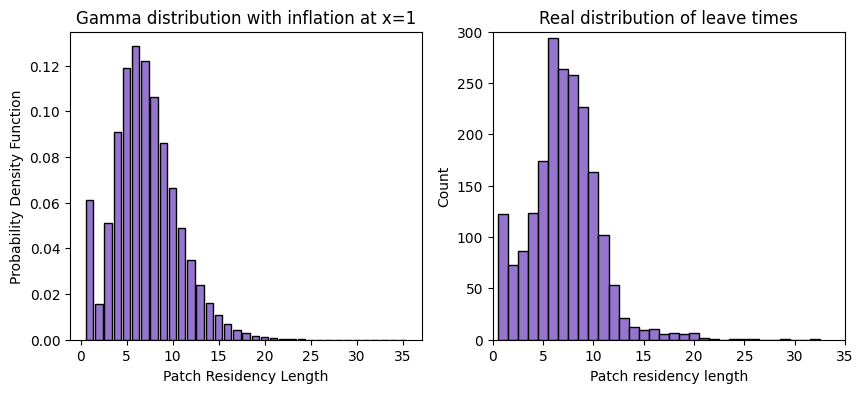

In [14]:
x2 = np.linspace(1, 35, 35)

color = 'blue'


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

y2 = gamma.cdf(x2, a=a, scale=s) - gamma.cdf(x2-1, a=a, scale=s)
reduction = 1 - pi
y2 *= reduction
y2[0] += pi

axs[0].bar(x2, y2, edgecolor="black", color="#9575cd")

axs[0].set_title('Gamma distribution with inflation at x=1')
axs[0].set_xlabel('Patch Residency Length')
axs[0].set_ylabel('Probability Density Function')


edges = np.arange(x.min(), x.max() + 2) - 0.5
_, bin_edges, _ = axs[1].hist(x, bins=edges, edgecolor="black", color="#9575cd")
axs[1].set_ylim(0, 300)
axs[1].set_xlim(0, 35)
axs[1].set_xlabel("Patch residency length")
axs[1].set_ylabel("Count")
axs[1].set_title(f"Real distribution of leave times")

plt.show()

### Step 7: Quantify the skew

In [21]:
sk = skew(patchLengths)
mean = np.mean(patchLengths)
median = np.median(patchLengths)

print(f"Skew: {round(sk, 3)}")
print(f"Mean is greater than Median = {(mean>median)}\nMean: {round(mean, 3)}, Median: {round(median, 3)}")

Skew: 0.951
Mean is greater than Median = True
Mean: 7.118, Median: 7.0


### Step 8: Fit some symmetric distributions

In [23]:
def nll_discrete_trunc_normal_inflated(params, x):
    "Negative log likelihood of discretised truncated normal distribution, extra probability injected at x=1"

    # unpack parameters
    mu, sigma, pi = params
    likelihoods = np.zeros_like(x, dtype=np.float64)

    # truncation normalisation (x >= 1)
    Z = 1 - norm.cdf(0, loc=mu, scale=sigma)

    # calculate likelihoods
    base_probs = (norm.cdf(x, loc=mu, scale=sigma) - 
                  norm.cdf(x - 1, loc=mu, scale=sigma)) / Z

    likelihoods = (1 - pi) * base_probs
    likelihoods[x == 1] += pi

    # prevent issues from log(0)
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_discrete_trunc_logistic_inflated(params, x):
    "Negative log likelihood of discretised truncated logistic distribution, extra probability injected at x=1"

    # unpack parameters
    mu, s, pi = params
    likelihoods = np.zeros_like(x, dtype=np.float64)

    # truncation normalisation (x >= 1)
    Z = 1 - logistic.cdf(0, loc=mu, scale=s)

    # calculate likelihoods
    base_probs = (logistic.cdf(x, loc=mu, scale=s) - 
                  logistic.cdf(x - 1, loc=mu, scale=s)) / Z

    likelihoods = (1 - pi) * base_probs
    likelihoods[x == 1] += pi

    # prevent issues from log(0)
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_binomial_inflated(params, x):
    "Negative log likelihood of zero-truncated binomial distribution, extra probability injected at x=1"

    # unpack parameters
    n_cont, p, pi = params
    likelihoods = np.zeros_like(x, dtype=np.float64)

    # convert n to integer
    n = int(round(n_cont))

    # invalid if n too small
    if n < np.max(x):
        return np.inf

    # truncation normalisation (remove x=0)
    Z = 1 - binom.pmf(0, n, p)
    if Z <= 0:
        return np.inf

    # calculate likelihoods
    base_probs = binom.pmf(x, n, p) / Z

    likelihoods = (1 - pi) * base_probs
    likelihoods[x == 1] += pi

    # prevent issues from log(0)
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

In [24]:
fitters.extend([

    DistributionFitter("discrete trunc normal_inf", 
                        nll_discrete_trunc_normal_inflated, 
                        [6.0, 2.0, 0.05], 
                        ["mu", "sigma", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discrete trunc logistic_inf", 
                        nll_discrete_trunc_logistic_inflated, 
                        [6.0, 2.0, 0.05], 
                        ["mu", "s", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("binomial_inf", 
                        nll_binomial_inflated, 
                        [np.max(patchLengths)+5, 0.5, 0.05], 
                        ["n", "p", "pi"],
                       bounds=[(np.max(patchLengths), 500), 
                               (1e-9, 1-1e-9),
                               (1e-9, 1-1e-9)]),

])

In [25]:
# fit to the obs and create the fitting dataframe
df = fit_distributions(patchLengths, fitters)
df

,distribution,params,aic,bic
0,discrete trunc logistic_inf,"{'mu': 6.59, 's': 1.85, 'pi': 0.04}",10388.45,10405.29
1,gamma_inf,"{'a': 4.79, 's': 1.46, 'pi': 0.06}",10489.38,10506.22
2,discretelog-logistic_inf,"{'k': 3.81, 'lambda_': 6.54, 'pi': 0.06}",10524.18,10541.02
3,discrete weibull_inf,"{'q': 0.99, 'beta': 2.23, 'pi': 0.05}",10545.62,10562.46
4,discrete trunc normal_inf,"{'mu': 6.56, 'sigma': 3.47, 'pi': 0.04}",10585.54,10602.38
5,discrete lognormal_inf,"{'mu': 1.84, 'sigma': 0.48, 'pi': 0.06}",10622.34,10639.18
6,discrete inverse gaussian inf,"{'r': 0.26, 'p': 26.87, 'pi': 0.06}",10681.21,10698.05
7,binomial_inf,"{'n': 37.0, 'p': 0.2, 'pi': 0.06}",10836.36,10853.20
8,geometric_inf,"{'p': 0.14, 'pi': 0.0}",11703.52,11714.74
9,discrete gompertz_inf,"{'eta': 0.29, 'beta': 6.35, 'pi': 0.0}",12492.68,12509.52


In [28]:
x

array([ 3.,  6.,  4., ...,  8., 15., 10.], shape=(2025,))

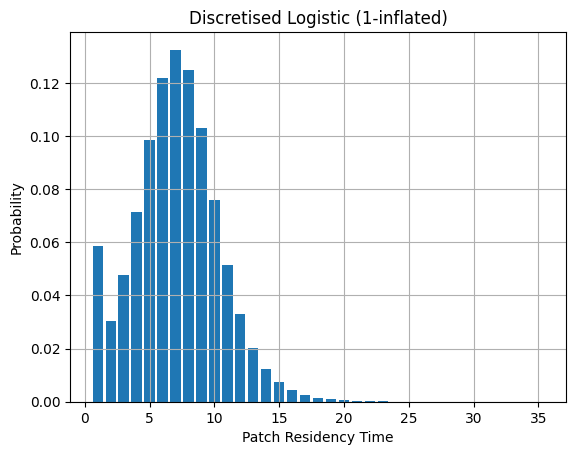

In [29]:
pi = 0.04
mu = 6.59
s = 1.85

# truncation (x >= 1)
Z = 1 - logistic.cdf(0, loc=mu, scale=s)

y3 = (logistic.cdf(x2, loc=mu, scale=s) - 
     logistic.cdf(x2 - 1, loc=mu, scale=s)) / Z

y3 *= (1 - pi)
y3[0] += pi

plt.bar(x2, y3)
plt.title('Discretised Logistic (1-inflated)')
plt.xlabel('Patch Residency Time')
plt.ylabel('Probability')
plt.grid(True)
plt.show()